In [6]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
from torch.nn.utils import weight_norm

import torch 
import torch.nn as nn 
import torch.nn.functional as F 

import numpy as np 
import matplotlib.pyplot as plt 
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd

In [4]:


class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()


class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()
        self.conv1 = weight_norm(nn.Conv1d(n_inputs, n_outputs, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation))
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = weight_norm(nn.Conv1d(n_outputs, n_outputs, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation))
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1,
                                 self.conv2, self.chomp2, self.relu2, self.dropout2)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()
        self.init_weights()

    def init_weights(self):
        self.conv1.weight.data.normal_(0, 0.01)
        self.conv2.weight.data.normal_(0, 0.01)
        if self.downsample is not None:
            self.downsample.weight.data.normal_(0, 0.01)

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=2, dropout=0.2):
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [TemporalBlock(in_channels, out_channels, kernel_size, stride=1, dilation=dilation_size,
                                     padding=(kernel_size-1) * dilation_size, dropout=dropout)]

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [5]:

class FullTCN(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=3, dropout=0.2, out_size=24):
        super().__init__()
        self.tcn = TemporalConvNet(num_inputs, num_channels, kernel_size, dropout)
        self.head = nn.Linear(num_channels[-1], out_size)

    def forward(self, x):
        # x: (batch, num_inputs, time)
        out = self.tcn(x)              # (batch, num_channels[-1], time)
        out = out[:, :, -1]            # last timestep: (batch, num_channels[-1])
        return self.head(out)          # (batch, out_size)

In [9]:
import os 
os.listdir('electricity-forecasting/data')


['AEP_hourly.csv',
 'COMED_hourly.csv',
 'DAYTON_hourly.csv',
 'DEOK_hourly.csv',
 'DOM_hourly.csv',
 'DUQ_hourly.csv',
 'EKPC_hourly.csv',
 'est_hourly.paruqet',
 'FE_hourly.csv',
 'NI_hourly.csv',
 'PJME_hourly.csv',
 'PJMW_hourly.csv',
 'pjm_hourly_est.csv',
 'PJM_Load_hourly.csv']

In [10]:
df = pd.read_csv("./electricity-forecasting/data/PJME_hourly.csv", parse_dates=["Datetime"]).sort_values("Datetime").reset_index(drop=True)

In [11]:
print(df.shape)
print(df.head()) 
print(df["Datetime"].min(), "->", df["Datetime"].max())

(145366, 2)
             Datetime  PJME_MW
0 2002-01-01 01:00:00  30393.0
1 2002-01-01 02:00:00  29265.0
2 2002-01-01 03:00:00  28357.0
3 2002-01-01 04:00:00  27899.0
4 2002-01-01 05:00:00  28057.0
2002-01-01 01:00:00 -> 2018-08-03 00:00:00


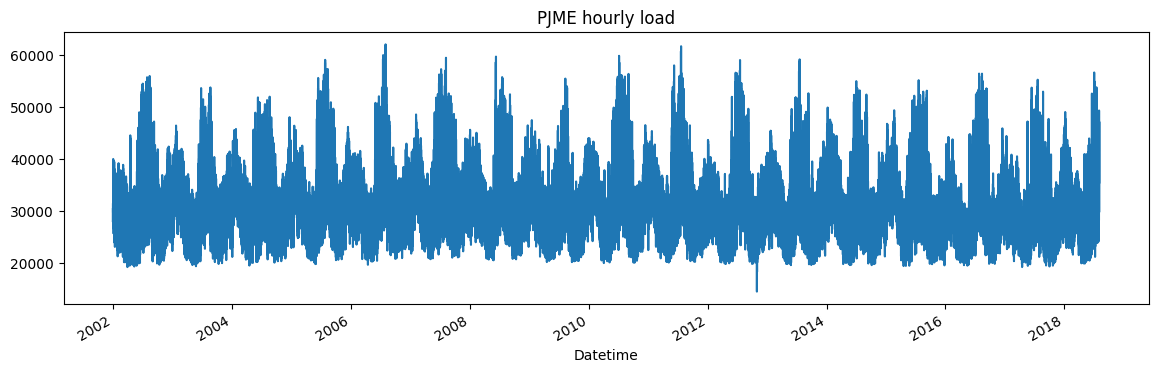

In [12]:
df.set_index("Datetime")["PJME_MW"].plot(figsize=(14,4)) 
plt.title("PJME hourly load")
plt.show()

In [13]:
def preprocess_data_multichannel(
        df,                                           # full DataFrame with Datetime + PJME_MW
        window: int = 168,
        horizon: int = 24,
        train_test_split: float = 0.8
):
    """
    Multi-channel input:
      ch 0: load (z-scored)
      ch 1: hour-of-day sin
      ch 2: hour-of-day cos
      ch 3: day-of-week sin
      ch 4: day-of-week cos
      ch 5: month sin
      ch 6: month cos
    """
    # Extract cyclical features from datetime
    dt = pd.to_datetime(df["Datetime"])
    hour = dt.dt.hour.values
    dow = dt.dt.dayofweek.values
    month = dt.dt.month.values

    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)
    dow_sin = np.sin(2 * np.pi * dow / 7)
    dow_cos = np.cos(2 * np.pi * dow / 7)
    month_sin = np.sin(2 * np.pi * (month - 1) / 12)
    month_cos = np.cos(2 * np.pi * (month - 1) / 12)

    load = df["PJME_MW"].to_numpy().astype(np.float32)

    # Stack into (n_features, n_timesteps)
    features = np.stack([
        load,
        hour_sin, hour_cos,
        dow_sin, dow_cos,
        month_sin, month_cos,
    ], axis=0).astype(np.float32)                    # shape (7, T)

    features_t = torch.from_numpy(features)          # (7, T)

    # Build windows: (T - window - horizon + 1, 7, window+horizon)
    # unfold creates (7, n_windows, window+horizon), permute to put windows first
    windows = features_t.unfold(1, window + horizon, 1).permute(1, 0, 2)
    # shape: (n_windows, 7, window+horizon)

    split = int(train_test_split * len(windows))
    full_train = windows[:split]
    full_test = windows[split:]

    # Z-score ONLY the load channel using train inputs
    train_load_inputs = full_train[:, 0, :window]    # (n_train, window)
    mean = train_load_inputs.mean()
    std = train_load_inputs.std()
    print(f"Load train mean: {mean.item():.2f}, std: {std.item():.2f}")

    # Apply normalization to channel 0 only (cyclical features already in [-1, 1])
    full_train_z = full_train.clone()
    full_test_z = full_test.clone()
    full_train_z[:, 0] = (full_train[:, 0] - mean) / std
    full_test_z[:, 0] = (full_test[:, 0] - mean) / std

    # Slice into X (input window) and Y (forecast horizon, load only)
    X_train = full_train_z[:, :, :window]            # (n_train, 7, window)
    Y_train = full_train_z[:, 0, window:]            # (n_train, horizon) — load only
    X_test = full_test_z[:, :, :window]
    Y_test = full_test_z[:, 0, window:]

    print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")
    print(f"X_test:  {X_test.shape}, Y_test:  {Y_test.shape}")

    train_ds = TensorDataset(X_train, Y_train)
    test_ds = TensorDataset(X_test, Y_test)
    train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

    return train_loader, test_loader, mean.item(), std.item()


train_loader, test_loader, mean, std = preprocess_data_multichannel(
    df, window=168, horizon=24
)

Load train mean: 32330.68, std: 6435.77
X_train: torch.Size([116140, 7, 168]), Y_train: torch.Size([116140, 24])
X_test:  torch.Size([29035, 7, 168]), Y_test:  torch.Size([29035, 24])


In [14]:
model = FullTCN(
    num_inputs=7,                        # load + 6 cyclical
    num_channels=[64]*5,                 # 5 blocks, 64 hidden each → RF=125
    kernel_size=3,
    dropout=0.2,
    out_size=24,
)

C:\Users\Jay\AppData\Roaming\Python\Python312\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [15]:
x_sample, y_sample = next(iter(train_loader))
print(f"Input shape: {x_sample.shape}")     # expect (256, 7, 168)
print(f"Output shape: {model(x_sample).shape}")  # expect (256, 24)

Input shape: torch.Size([256, 7, 168])
Output shape: torch.Size([256, 24])


In [16]:
from datetime import datetime

def train_test_loop(
        model: nn.Module,
        train_loader: DataLoader,
        test_loader: DataLoader,
        lr: float = 1e-3,
        epochs: int = 5
    ):
    start = datetime.now()
    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses = []
    for epoch in range(epochs): 
        print(f"Epoch: {epoch}")
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            train_losses.append(loss.item())
        avg_loss = running_loss / len(train_loader) 
        # print(f"Epoch {epoch+1:3d}: MSE = {avg_loss:.4f}")
    end = datetime.now()
    training_time = (end - start).total_seconds()
    print(f"Total Training Time: {training_time:.1f} seconds")

    # test loop
    model.eval()
    test_loss = 0
    test_losses = []
    with torch.no_grad():
        for xb, yb in test_loader:
            pred = model(xb)
            loss = loss_fn(pred, yb)
            test_loss += loss.item()
            test_losses.append(loss.item())
    test_mse = test_loss / len(test_loader)
    print(f"Test MSE: {test_mse:.6f}")
    test_mse_mw = test_mse * (std ** 2)              # MSE scales with variance, hence std²
    test_rmse_mw = np.sqrt(test_mse_mw)              # RMSE in MW
    print(f"Test RMSE (MW): {test_rmse_mw:.0f}")
    return test_mse, np.array(test_losses), np.array(train_losses)

In [18]:
test_mse, _, _ = train_test_loop(
    model, train_loader, test_loader,
    lr=1e-3, epochs=2,                   # start with 2 like the bare TCN run
)


Epoch: 0
Epoch: 1
Total Training Time: 204.0 seconds
Test MSE: 0.091189
Test RMSE (MW): 1943


In [19]:
test_rmse_mw = (test_mse ** 0.5) * std
print(f"Test RMSE (MW): {test_rmse_mw:.0f}")

Test RMSE (MW): 1943


In [20]:
# Seasonal naïve: prediction for next 24h = same 24h from one week ago
# In your sliding-window setup, the first 24h of the input window IS one week ago

import numpy as np

# Iterate test loader, compute naive baseline in z-scored space, then de-normalize
naive_mses = []
for xb, yb in test_loader:
    # xb shape: (batch, 1, 168). Take first 24h of input as the prediction.
    pred_naive = xb[:, 0, :24]                # (batch, 24)
    mse = ((pred_naive - yb) ** 2).mean().item()
    naive_mses.append(mse)

naive_mse_z = np.mean(naive_mses)
naive_rmse_mw = np.sqrt(naive_mse_z * std**2)
print(f"Seasonal naïve RMSE (MW): {naive_rmse_mw:.0f}")

Seasonal naïve RMSE (MW): 4670


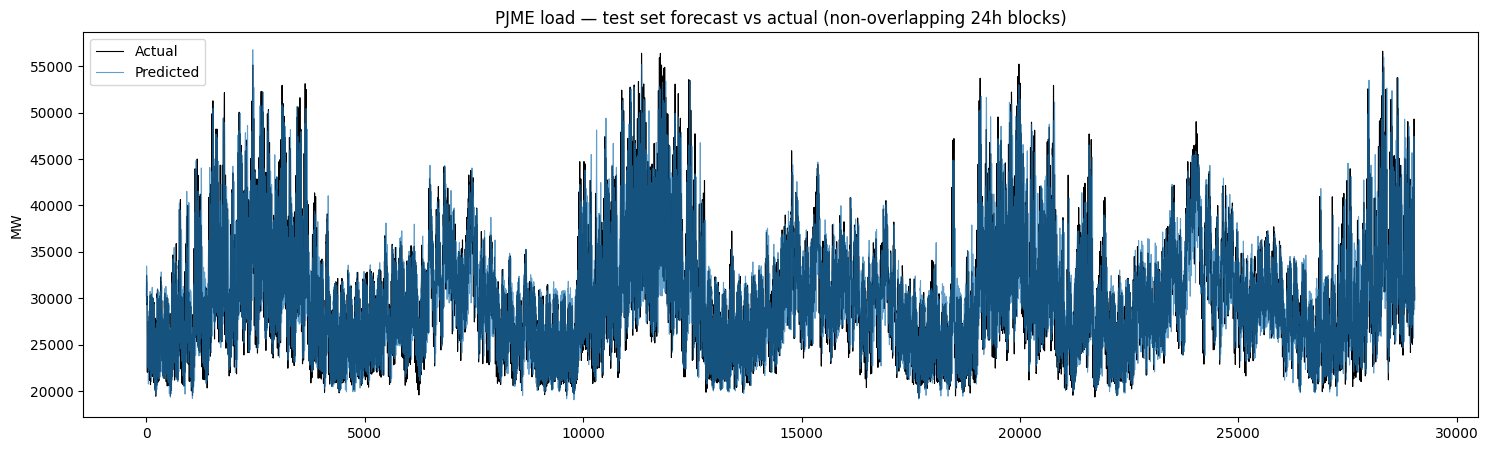

In [22]:

preds_all, actuals_all = [], []
model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        preds_all.append(model(xb))
        actuals_all.append(yb)
preds_all = torch.cat(preds_all).numpy()       # (N, 24) z-scored
actuals_all = torch.cat(actuals_all).numpy()

# De-normalize
preds_mw = preds_all * std + mean
actuals_mw = actuals_all * std + mean

# Non-overlapping forecasts (every 24th sample → flatten 24-hour blocks)
step = 24
preds_flat = preds_mw[::step].flatten()
actuals_flat = actuals_mw[::step].flatten()

plt.figure(figsize=(18, 5))
plt.plot(actuals_flat, color="black", linewidth=0.8, label="Actual")
plt.plot(preds_flat, color="C0", linewidth=0.8, alpha=0.7, label="Predicted")
plt.title("PJME load — test set forecast vs actual (non-overlapping 24h blocks)")
plt.ylabel("MW")
plt.legend()
plt.show()

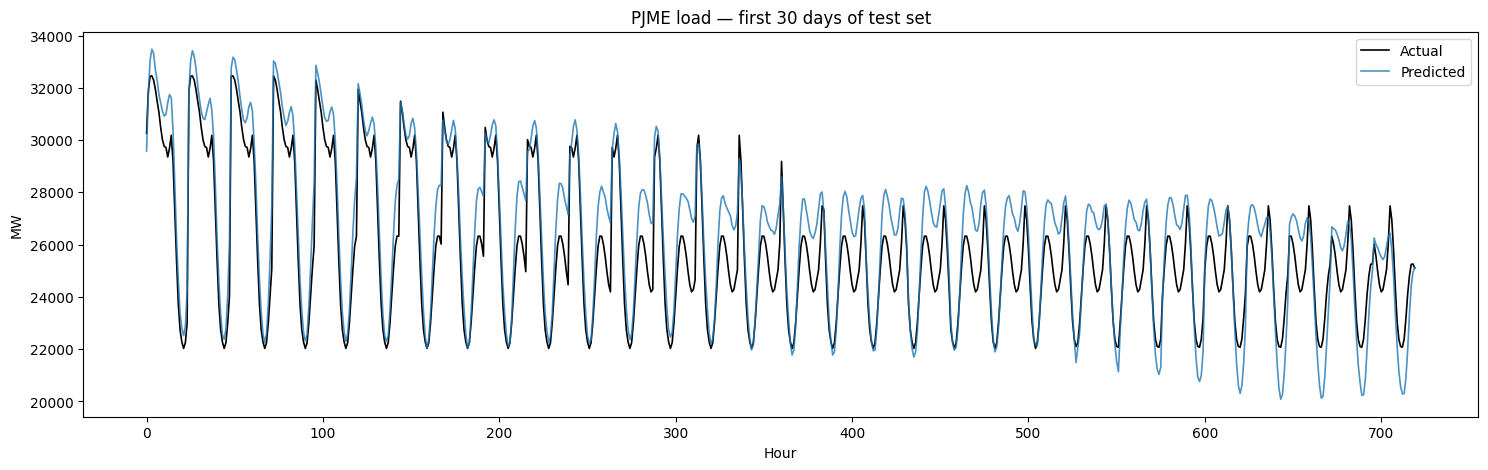

In [23]:
# Plot first ~30 days of test set (720 hours ≈ 30 non-overlapping 24h blocks)
n_blocks = 30
plt.figure(figsize=(18, 5))
plt.plot(actuals_mw[:n_blocks].flatten(), "black", label="Actual", linewidth=1.2)
plt.plot(preds_mw[:n_blocks].flatten(), "C0", label="Predicted", linewidth=1.2, alpha=0.8)
plt.title("PJME load — first 30 days of test set")
plt.ylabel("MW")
plt.xlabel("Hour")
plt.legend()
plt.show()

In [24]:
# Recompute z-space stats and correlation for the new model
print(f"Predictions z-space: mean={preds_all.mean():.3f}, std={preds_all.std():.3f}")
print(f"Actuals z-space:     mean={actuals_all.mean():.3f}, std={actuals_all.std():.3f}")

correlations = []
for i in range(len(preds_all)):
    c = np.corrcoef(preds_all[i], actuals_all[i])[0, 1]
    correlations.append(c)
correlations = np.array(correlations)
print(f"Mean correlation: {correlations.mean():.3f}")
print(f"Median correlation: {np.median(correlations):.3f}")
print(f"Frac > 0.8: {(correlations > 0.8).mean():.2%}")

# RMSE
test_rmse_mw = np.sqrt(test_mse) * std
print(f"Test RMSE (MW): {test_rmse_mw:.0f}")
print(f"Seasonal naïve baseline: 4670 MW")
print(f"Bare TCN single-channel: 2299 MW")

Predictions z-space: mean=-0.141, std=0.996
Actuals z-space:     mean=-0.194, std=1.008
Mean correlation: 0.958
Median correlation: 0.978
Frac > 0.8: 97.31%
Test RMSE (MW): 1943
Seasonal naïve baseline: 4670 MW
Bare TCN single-channel: 2299 MW
